In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import Binarizer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Load data and select explicit columns
df = pd.read_csv('tested_titanic.csv', usecols=['Age', 'Fare', 'SibSp', 'Parch', 'Survived'])
df.dropna(inplace=True)

# 2. Engineer features
df['Family'] = df['SibSp'] + df['Parch']
df.drop(columns=['SibSp', 'Parch'], inplace=True)

# 3. Define features (X) and target (y)
X = df[['Age', 'Fare', 'Family']]
y = df['Survived'].astype(int)  # Explicitly cast to discrete int

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Apply ColumnTransformer with Binarizer on 'Family' by name
trf = ColumnTransformer(
    transformers=[('binarizer', Binarizer(threshold=0.0), ['Family'])],
    remainder='passthrough'
)

# 6. Transform data
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

# 7. Impute & Train
imputer = SimpleImputer(strategy='mean')
X_train_trf = imputer.fit_transform(X_train_trf)
X_test_trf = imputer.transform(X_test_trf)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_trf, y_train)

# 8. Evaluate
y_pred = clf.predict(X_test_trf)
print("Accuracy with Binarization:", accuracy_score(y_test, y_pred))

Accuracy with Binarization: 0.6119402985074627


In [29]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy without Binning:", accuracy_score(y_test, y_pred))

# Cross-validation score
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy'))

Accuracy without Binning: 0.5970149253731343


np.float64(0.6073083778966132)

In [31]:
def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    
    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])
    
    X_trf = trf.fit_transform(X)
    print("Cross-Val Score:", np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, y, cv=10, scoring='accuracy')))
    
    plt.figure(figsize=(14, 4))
    
    # Age plot before & after
    plt.subplot(1, 2, 1)
    plt.hist(X['Age'], color='red', alpha=0.5, label='Before')
    plt.hist(X_trf[:, 0], color='blue', alpha=0.5, label='After')
    plt.title('Age Distribution')
    plt.legend()
    
    # Fare plot before & after
    plt.subplot(1, 2, 2)
    plt.hist(X['Fare'], color='red', alpha=0.5, label='Before')
    plt.hist(X_trf[:, 1], color='blue', alpha=0.5, label='After')
    plt.title('Fare Distribution')
    plt.legend()
    
    plt.show()

# Example usages:
# discretize(10, 'quantile')
# discretize(10, 'uniform')
# discretize(10, 'kmeans')

Cross-Val Score: 0.5590909090909092


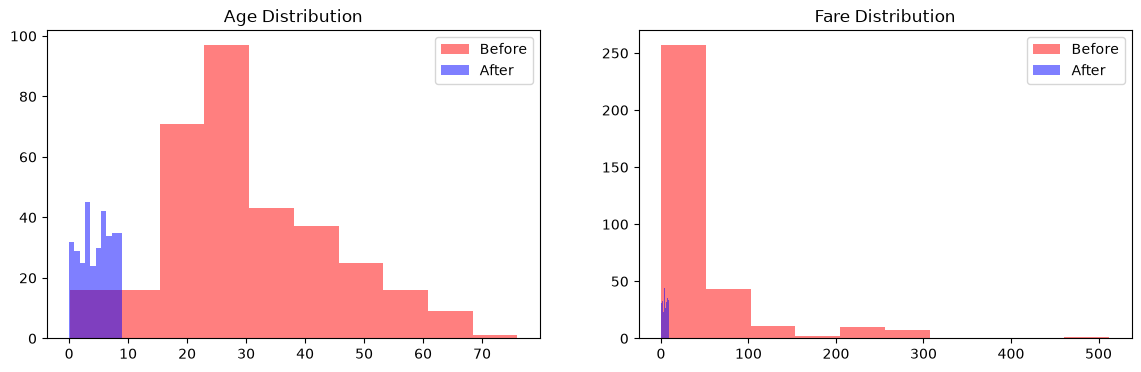

Cross-Val Score: 0.5923351158645277


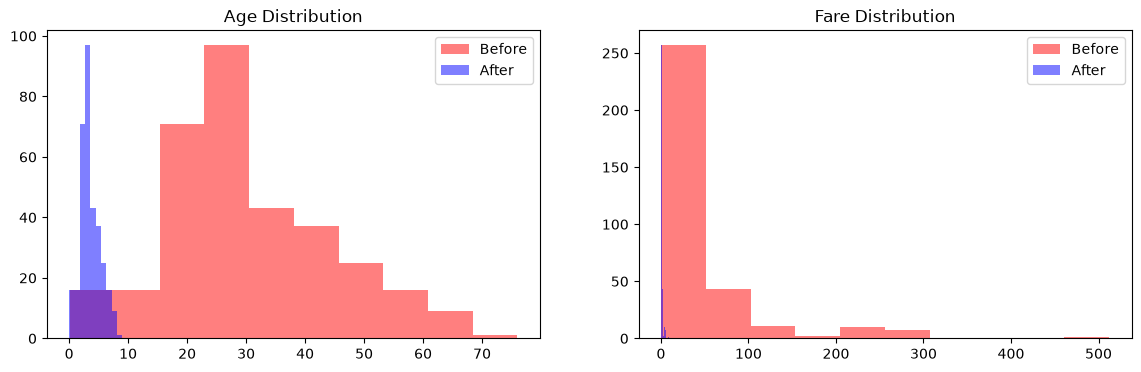

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Cross-Val Score: 0.6014260249554367


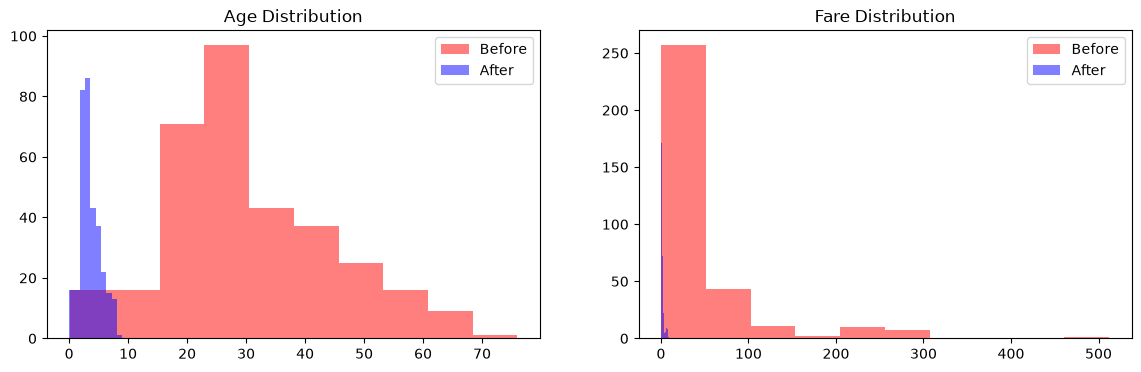

In [36]:
# 1. Quantile Binning (Equal number of samples per bin)
discretize(10, 'quantile')

# 2. Uniform Binning (Equal width for each bin)
discretize(10, 'uniform')

# 3. K-Means Clustering Binning (Groups values into clusters)
discretize(10, 'kmeans')

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ('transform', ColumnTransformer(
        transformers=[('log', FunctionTransformer(np.log1p), ['Fare'])],
        remainder='passthrough'
    )),
    ('imputer', SimpleImputer(strategy='mean')),
    ('clf', LogisticRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy LR:", accuracy_score(y_test, y_pred))

Accuracy LR: 0.7164179104477612


In [33]:
from sklearn.preprocessing import Binarizer
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Load dataset with correct filename
df = pd.read_csv('tested_titanic.csv', usecols=['Age', 'Fare', 'SibSp', 'Parch', 'Survived'])
df.dropna(inplace=True)

# 2. Create 'Family' feature
df['Family'] = df['SibSp'] + df['Parch']
df.drop(columns=['SibSp', 'Parch'], inplace=True)

# 3. Define features (X) and target (y)
X = df.drop(columns=['Survived'])
y = df['Survived'].astype(int)  # Explicitly cast to int to prevent continuous label error

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Pass ['Family'] by name instead of index [2]
trf = ColumnTransformer([
    ('binarizer', Binarizer(threshold=0.0, copy=False), ['Family'])
], remainder='passthrough')

X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

# Train and evaluate model with binarized feature
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred = clf.predict(X_test_trf)
print("Accuracy with Binarization:", accuracy_score(y_test, y_pred))

Accuracy with Binarization: 0.6119402985074627


In [35]:
# Transform 'Family' into a binary indicator: 0 if traveling alone, 1 if traveling with family
trf = ColumnTransformer([
    ('binarizer', Binarizer(threshold=0.0, copy=False), [2])
], remainder='passthrough')

X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

# Train and evaluate model with binarized feature
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)

y_pred = clf.predict(X_test_trf)
print("Accuracy with Binarization:", accuracy_score(y_test, y_pred))

Accuracy with Binarization: 0.6119402985074627


In [39]:
# Reconstruct into a readable Pandas DataFrame
df_bin_transformed = pd.DataFrame(
    X_bin_trf, 
    columns=['Family_Binarized', 'Age', 'Fare']
)

df_bin_transformed.head()

,Family_Binarized,Age,Fare
0,1.0,0.75,13.7750
1,1.0,76.00,78.8500
2,0.0,32.00,7.5792
3,1.0,27.00,7.9250
4,1.0,22.00,61.9792
